In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import os
from pathlib import Path
import glob
import json
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append("/code")
import bg_spatial_plots.plot_spatial_histograms as histplot
from plot_confusion_matrix import plot_confusion_matrix

%matplotlib inline

In [3]:
output_fig_dir = '/scratch/mat_paper_figures/for_YF_astro'
os.makedirs(output_fig_dir, exist_ok=True)

plt.rcParams.update({'font.size': 6})

# to get text as text and not paths in Illustrator
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# this can mess with some plots, use cautiously
# plt.rcParams['figure.constrained_layout.use'] = True

# Load data

In [4]:
adata_rnaseq_selfmap = ad.read_h5ad(
    '/data/human_snRNAseq_astrocyte_MMC_results_with_Astro_SubGroups/HMBA_human_Astro_3subGroups_mmc_mapped-withAstroSubGroups.h5ad',
)
adata_rnaseq_selfmap

AnnData object with n_obs × n_vars = 134124 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'donor_id', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac_non_nuclear_read_pairs', 'atac_number_of_peaks', 'atac_percent_duplicates', 'atac_q30_bases_in_barcode', 'atac_q30_bases_in_read_1', 'atac_q30_bases_in_read_2', 'atac_q30_bases_in_s

In [5]:
adata_spatial_remap = ad.read_h5ad('/data/human_spatial_astrocyte_MMC_results_with_Astro_SubGroups/human_spatial_astrocytes_extended_mmc_results_UMAP_colors_mmc_mapped-withAstroSubGroups.h5ad')
adata_spatial_remap

AnnData object with n_obs × n_vars = 641913 × 299
    obs: 'x', 'y', 'brain_section_label', 'brain_section_barcode', 'slab', 'block', 'set', 'z_order', 'total_counts', 'total_counts_genes', 'n_genes_by_counts', 'total_counts_Blank', 'pct_counts_Blank', 'genes_filter', 'counts_filter', 'blanks_filter', 'qc_pass', 'doublets_filter', 'qc_pass_and_singlet', 'doublet_singlet_score_diff', 'doublet_diff_threshold', 'hierarchy_consistent', 'Neighborhood', 'Neighborhood_bootstrapping_probability', 'Neighborhood_correlation_coefficient', 'Class', 'Class_bootstrapping_probability', 'Class_correlation_coefficient', 'Subclass', 'Subclass_bootstrapping_probability', 'Subclass_correlation_coefficient', 'Group', 'Group_bootstrapping_probability', 'Group_correlation_coefficient', 'cluster_id', 'cluster_id_bootstrapping_probability', 'cluster_id_correlation_coefficient', 'Neighborhood_entropy', 'Class_entropy', 'Subclass_entropy', 'Group_entropy', 'cluster_id_entropy', 'STAligner_mclust_res_10_knn_15', 

## filter down to just the mapped astrocytes

In [14]:
adata_rnaseq_selfmap_astro = adata_rnaseq_selfmap[adata_rnaseq_selfmap.obs['CDM_Group_label']=='Astrocyte'].copy()
adata_rnaseq_selfmap_astro

AnnData object with n_obs × n_vars = 132667 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'donor_id', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac_non_nuclear_read_pairs', 'atac_number_of_peaks', 'atac_percent_duplicates', 'atac_q30_bases_in_barcode', 'atac_q30_bases_in_read_1', 'atac_q30_bases_in_read_2', 'atac_q30_bases_in_s

In [15]:
adata_spatial_remap_astro = adata_spatial_remap[adata_spatial_remap.obs['CDM_Group_label']=='Astrocyte'].copy()
adata_spatial_remap_astro

AnnData object with n_obs × n_vars = 618323 × 299
    obs: 'x', 'y', 'brain_section_label', 'brain_section_barcode', 'slab', 'block', 'set', 'z_order', 'total_counts', 'total_counts_genes', 'n_genes_by_counts', 'total_counts_Blank', 'pct_counts_Blank', 'genes_filter', 'counts_filter', 'blanks_filter', 'qc_pass', 'doublets_filter', 'qc_pass_and_singlet', 'doublet_singlet_score_diff', 'doublet_diff_threshold', 'hierarchy_consistent', 'Neighborhood', 'Neighborhood_bootstrapping_probability', 'Neighborhood_correlation_coefficient', 'Class', 'Class_bootstrapping_probability', 'Class_correlation_coefficient', 'Subclass', 'Subclass_bootstrapping_probability', 'Subclass_correlation_coefficient', 'Group', 'Group_bootstrapping_probability', 'Group_correlation_coefficient', 'cluster_id', 'cluster_id_bootstrapping_probability', 'cluster_id_correlation_coefficient', 'Neighborhood_entropy', 'Class_entropy', 'Subclass_entropy', 'Group_entropy', 'cluster_id_entropy', 'STAligner_mclust_res_10_knn_15', 

In [38]:
rnaseq_selfmap_metrics = adata_rnaseq_selfmap_astro.obs[
    [
        'CDM_Group_aggregate_probability',
        'CDM_Group_avg_correlation',
        'CDM_Group_bootstrapping_probability',
        'CDM_Group_label',
        'CDM_Group_runner_up_assignment_0',
        'CDM_Group_runner_up_assignment_1',
        'CDM_SubGroup_aggregate_probability',
        'CDM_SubGroup_avg_correlation',
        'CDM_SubGroup_bootstrapping_probability',
        'CDM_SubGroup_label',
        'CDM_SubGroup_runner_up_assignment_0',
        'CDM_SubGroup_runner_up_assignment_1',
        'CDM_cluster_id_aggregate_probability',
        'CDM_cluster_id_avg_correlation',
        'CDM_cluster_id_bootstrapping_probability',
        'CDM_cluster_id_label',
        'CDM_cluster_id_runner_up_assignment_0',
        'CDM_cluster_id_runner_up_assignment_1',
    ]
].copy()

spatial_remap_metrics = adata_spatial_remap_astro.obs[
    [
        'CDM_Group_aggregate_probability',
        'CDM_Group_avg_correlation',
        'CDM_Group_bootstrapping_probability',
        'CDM_Group_label',
        'CDM_Group_runner_up_assignment_0',
        'CDM_Group_runner_up_assignment_1',
        'CDM_SubGroup_aggregate_probability',
        'CDM_SubGroup_avg_correlation',
        'CDM_SubGroup_bootstrapping_probability',
        'CDM_SubGroup_label',
        'CDM_SubGroup_runner_up_assignment_0',
        'CDM_SubGroup_runner_up_assignment_1',
        'CDM_cluster_id_aggregate_probability',
        'CDM_cluster_id_avg_correlation',
        'CDM_cluster_id_bootstrapping_probability',
        'CDM_cluster_id_label',
        'CDM_cluster_id_runner_up_assignment_0',
        'CDM_cluster_id_runner_up_assignment_1',
    ]
].copy()

rnaseq_selfmap_metrics['dataset'] = 'snRNA-seq'
spatial_remap_metrics['dataset'] = 'MERSCOPE'

combined_metrics = pd.concat([rnaseq_selfmap_metrics, spatial_remap_metrics], axis=0)

# filter out mixed
combined_metrics = combined_metrics[combined_metrics['CDM_SubGroup_label'].isin(subgroup_palette.keys())].copy()  # filter to subgroups of interest
# reset category to remove unused categories
combined_metrics['CDM_SubGroup_label'] = combined_metrics['CDM_SubGroup_label'].cat.remove_unused_categories()
combined_metrics.head()

,CDM_Group_aggregate_probability,CDM_Group_avg_correlation,CDM_Group_bootstrapping_probability,CDM_Group_label,CDM_Group_runner_up_assignment_0,CDM_Group_runner_up_assignment_1,CDM_SubGroup_aggregate_probability,CDM_SubGroup_avg_correlation,CDM_SubGroup_bootstrapping_probability,CDM_SubGroup_label,CDM_SubGroup_runner_up_assignment_0,CDM_SubGroup_runner_up_assignment_1,CDM_cluster_id_aggregate_probability,CDM_cluster_id_avg_correlation,CDM_cluster_id_bootstrapping_probability,CDM_cluster_id_label,CDM_cluster_id_runner_up_assignment_0,CDM_cluster_id_runner_up_assignment_1,dataset
AAACAGCCATTGTGGC-2362_A05,1.0,0.766221,1.0,Astrocyte,NaN,NaN,1.0,0.766221,1.0,GM STR,NaN,NaN,1.00,0.766221,1.00,Human-7,NaN,NaN,snRNA-seq
AAACATGCAGTAGGAT-2362_A05,1.0,0.741158,1.0,Astrocyte,NaN,NaN,1.0,0.741158,1.0,GM exSTR,NaN,NaN,0.93,0.741267,0.93,Human-145,Human-159,Human-450,snRNA-seq
AAACCGCGTTGACTTC-2362_A05,1.0,0.789106,1.0,Astrocyte,NaN,NaN,1.0,0.789106,1.0,GM STR,NaN,NaN,1.00,0.789106,1.00,Human-14,NaN,NaN,snRNA-seq
AAAGCGGGTCATCATC-2362_A05,1.0,0.780374,1.0,Astrocyte,NaN,NaN,1.0,0.780374,1.0,GM exSTR,NaN,NaN,0.96,0.780427,0.96,Human-160,Human-159,NaN,snRNA-seq
AAAGGACGTTCGCTTG-2362_A05,1.0,0.773385,1.0,Astrocyte,NaN,NaN,1.0,0.773385,1.0,GM exSTR,NaN,NaN,1.00,0.773385,1.00,Human-159,NaN,NaN,snRNA-seq


In [24]:
subgroup_palette = adata_spatial_remap_astro.uns['SubGroup_color_dict']
subgroup_palette

{'GM STR': '#487cb4',
 'GM exSTR': '#65ab55',
 'Mixed': '#999999',
 'Non-Astrocyte': '#cccccc',
 'WM': '#d23b33'}

{'GM STR': '#487cb4', 'GM exSTR': '#65ab55', 'WM': '#d23b33'}

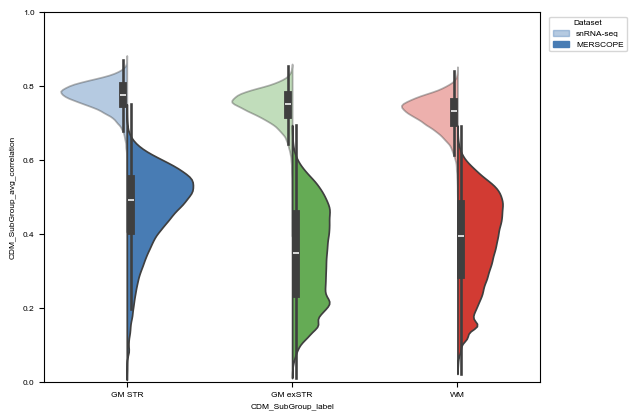

In [95]:
from matplotlib.patches import Patch
subgroup_palette = {key: adata_spatial_remap_astro.uns['SubGroup_color_dict'][key] for key in ['GM STR', 'GM exSTR', 'WM']}
display(subgroup_palette)

fig, ax = plt.subplots()

ax = sns.violinplot(
    data=combined_metrics,
    x='CDM_SubGroup_label',       # categorical grouping (optional but typical)
    y='CDM_SubGroup_avg_correlation',       # your metric
    hue='dataset',    # df1 vs df2
    split=True,
    cut=0,
    inner='box'
)

# Re-color violins by x-group
groups = list(subgroup_palette.keys())
from matplotlib.collections import PolyCollection

violins = [c for c in ax.collections if isinstance(c, PolyCollection)]

# With split=True, each group has 2 halves: index 0,1 = group 0; 2,3 = group 1; etc.
for i, poly in enumerate(violins):
    group_idx = i // 2
    if group_idx >= len(groups):
        continue
    group = groups[group_idx]
    base = subgroup_palette[group]

    poly.set_facecolor(base)

    if i % 2 == 1:
        poly.set_alpha(1.0)   # second dataset half
    else:
        poly.set_alpha(0.4)   # first dataset half

color = subgroup_palette['GM STR']
legend_handles = [
    Patch(color=color, alpha=0.4, label='snRNA-seq'),
    Patch(color=color, alpha=1.0, label='MERSCOPE'),
]
ax.legend(handles=legend_handles, title='Dataset',
            bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)

ax.set_ylim(0, 1)

plt.show()

fig.savefig(os.path.join(output_fig_dir, 'subgroup_avg_corr_violin_split.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'subgroup_avg_corr_violin_split.png'), bbox_inches='tight', dpi=300)

/tmp/ipykernel_133287/3378642476.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)


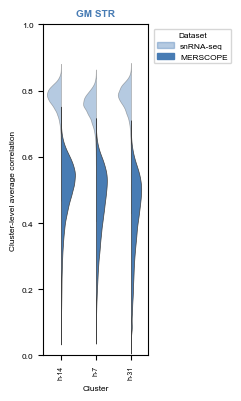

/tmp/ipykernel_133287/3378642476.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)


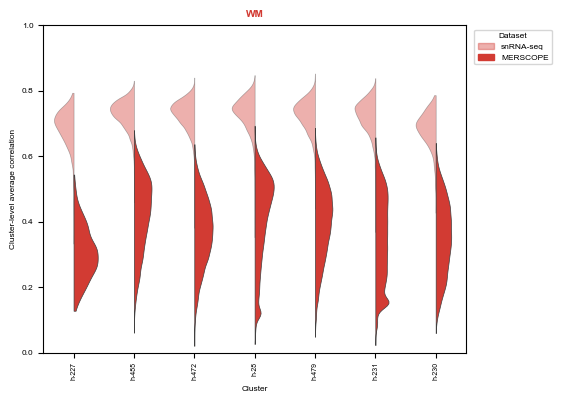

/tmp/ipykernel_133287/3378642476.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)


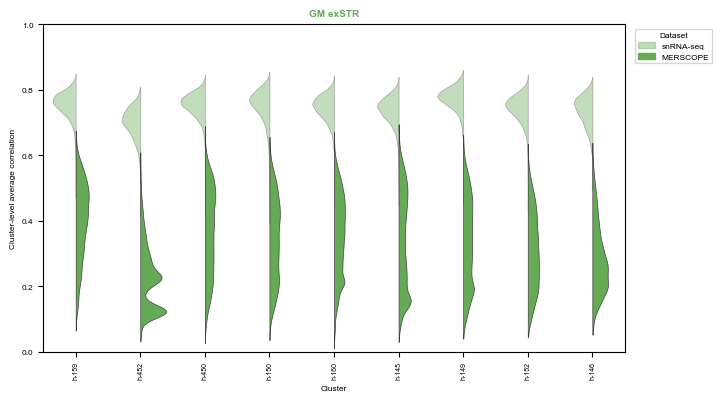

In [97]:
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

# ── Palette & subgroup order ──────────────────────────────────────────────────
subgroup_palette = {key: adata_spatial_remap_astro.uns['SubGroup_color_dict'][key] for key in ['GM STR', 'WM', 'GM exSTR']}
astro_subgroups = list(subgroup_palette.keys())

# ── Cluster ordering ──────────────────────────────────────────────────────────
combined_metrics_plot = combined_metrics.copy()
combined_metrics_plot['cluster_id_short'] = (
    combined_metrics_plot['CDM_cluster_id_label']
    .astype(str)
    .str.replace('Human-', 'h-', regex=False)
)
combined_metrics_plot['SubGroup'] = combined_metrics_plot['CDM_SubGroup_label'].astype(str)

cluster_means = (
    combined_metrics_plot[combined_metrics_plot['SubGroup'].isin(astro_subgroups)]
    .groupby('cluster_id_short', observed=True)['CDM_cluster_id_avg_correlation']
    .mean()
    .reset_index()
    .rename(columns={'CDM_cluster_id_avg_correlation': 'mean_val'})
)
cluster_means['SubGroup'] = cluster_means['cluster_id_short'].map(
    combined_metrics_plot.drop_duplicates('cluster_id_short')
    .set_index('cluster_id_short')['SubGroup']
)
cluster_means = cluster_means[cluster_means['SubGroup'].isin(astro_subgroups)]
cluster_means['SubGroup'] = pd.Categorical(cluster_means['SubGroup'], categories=astro_subgroups, ordered=True)
cluster_means = cluster_means.sort_values(['SubGroup', 'mean_val'], ascending=[True, False])

# ── One figure per SubGroup ───────────────────────────────────────────────────
PLOT_HEIGHT = 4

for subgroup in astro_subgroups:
    sg_clusters = cluster_means.loc[cluster_means['SubGroup'] == subgroup, 'cluster_id_short'].tolist()
    n_clusters = len(sg_clusters)
    sg_data = combined_metrics_plot[combined_metrics_plot['cluster_id_short'].isin(sg_clusters)]

    fig, ax = plt.subplots(figsize=(n_clusters * 0.8, PLOT_HEIGHT))

    sns.violinplot(
        data=sg_data,
        x='cluster_id_short',
        y='CDM_cluster_id_avg_correlation',
        hue='dataset',
        split=True,
        order=sg_clusters,
        inner=None,
        linewidth=0.5,
        ax=ax,
        cut=0,
    )

    # Re-color violins
    color = subgroup_palette[subgroup]
    violins = [c for c in ax.collections if isinstance(c, PolyCollection)]
    for i, poly in enumerate(violins):
        poly.set_facecolor(color)
        poly.set_alpha(0.4 if i % 2 == 0 else 1.0)  # faded = snRNA-seq, full = MERSCOPE

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Cluster-level average correlation')
    ax.set_ylim(0, 1)
    ax.set_title(subgroup, color=color, fontweight='bold')

    legend_handles = [
        Patch(color=color, alpha=0.4, label='snRNA-seq'),
        Patch(color=color, alpha=1.0, label='MERSCOPE'),
    ]
    ax.legend(handles=legend_handles, title='Dataset',
              bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)

    # Lines include whiskers, box edges, medians
    for line in ax.lines:
        line.set_color("black")     # or whatever you want
        line.set_linewidth(1.0)

    plt.tight_layout()
    plt.show()

    fig.savefig(os.path.join(output_fig_dir, f'cluster_avg_corr_violin_split_subgroup{subgroup}.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(output_fig_dir, f'cluster_avg_corr_violin_split_subgroup{subgroup}.png'), bbox_inches='tight', dpi=300)

{'GM STR': '#487cb4', 'GM exSTR': '#65ab55', 'WM': '#d23b33'}

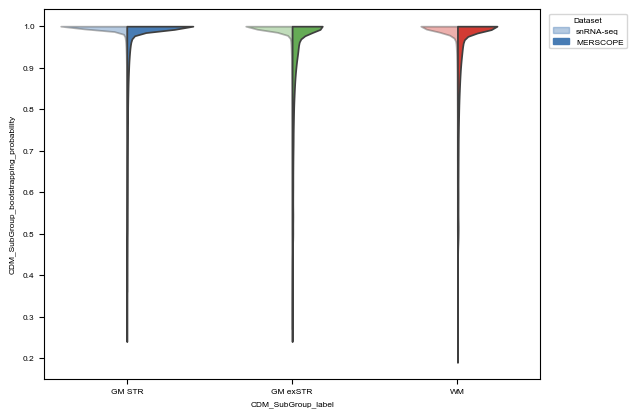

In [72]:
from matplotlib.patches import Patch
subgroup_palette = {key: adata_spatial_remap_astro.uns['SubGroup_color_dict'][key] for key in ['GM STR', 'GM exSTR', 'WM']}
display(subgroup_palette)

fig, ax = plt.subplots()

ax = sns.violinplot(
    data=combined_metrics,
    x='CDM_SubGroup_label',       # categorical grouping (optional but typical)
    y='CDM_SubGroup_bootstrapping_probability',       # your metric
    hue='dataset',    # df1 vs df2
    split=True,
    cut=0,
    inner=None
)

# Re-color violins by x-group
groups = list(subgroup_palette.keys())
from matplotlib.collections import PolyCollection

violins = [c for c in ax.collections if isinstance(c, PolyCollection)]

# With split=True, each group has 2 halves: index 0,1 = group 0; 2,3 = group 1; etc.
for i, poly in enumerate(violins):
    group_idx = i // 2
    if group_idx >= len(groups):
        continue
    group = groups[group_idx]
    base = subgroup_palette[group]

    poly.set_facecolor(base)

    if i % 2 == 1:
        poly.set_alpha(1.0)   # second dataset half
    else:
        poly.set_alpha(0.4)   # first dataset half

color = subgroup_palette['GM STR']
legend_handles = [
    Patch(color=color, alpha=0.4, label='snRNA-seq'),
    Patch(color=color, alpha=1.0, label='MERSCOPE'),
]
ax.legend(handles=legend_handles, title='Dataset',
            bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)

ax.set_ylim(0.15, None)

plt.show()

fig.savefig(os.path.join(output_fig_dir, 'subgroup_bootstrapping_violin_split.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'subgroup_bootstrapping_violin_split.png'), bbox_inches='tight', dpi=300)

/tmp/ipykernel_133287/1960406535.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)


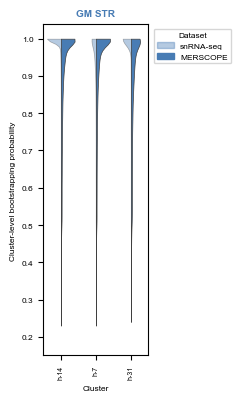

/tmp/ipykernel_133287/1960406535.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)


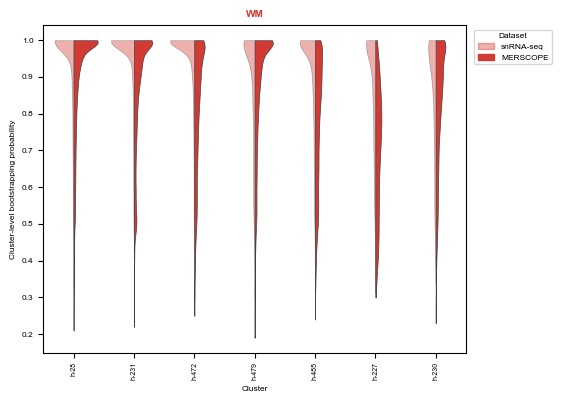

/tmp/ipykernel_133287/1960406535.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)


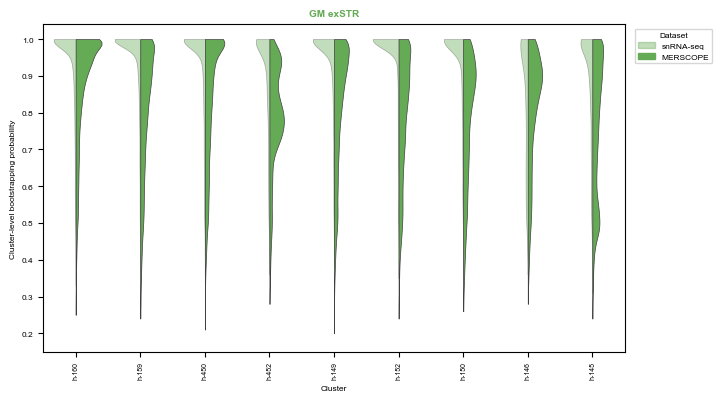

In [ ]:
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

# ── Palette & subgroup order ──────────────────────────────────────────────────
subgroup_palette = {key: adata_spatial_remap_astro.uns['SubGroup_color_dict'][key] for key in ['GM STR', 'WM', 'GM exSTR']}
astro_subgroups = list(subgroup_palette.keys())

# ── Cluster ordering ──────────────────────────────────────────────────────────
combined_metrics_plot = combined_metrics.copy()
combined_metrics_plot['cluster_id_short'] = (
    combined_metrics_plot['CDM_cluster_id_label']
    .astype(str)
    .str.replace('Human-', 'h-', regex=False)
)
combined_metrics_plot['SubGroup'] = combined_metrics_plot['CDM_SubGroup_label'].astype(str)

cluster_means = (
    combined_metrics_plot[combined_metrics_plot['SubGroup'].isin(astro_subgroups)]
    .groupby('cluster_id_short', observed=True)['CDM_cluster_id_bootstrapping_probability']
    .mean()
    .reset_index()
    .rename(columns={'CDM_cluster_id_bootstrapping_probability': 'mean_val'})
)
cluster_means['SubGroup'] = cluster_means['cluster_id_short'].map(
    combined_metrics_plot.drop_duplicates('cluster_id_short')
    .set_index('cluster_id_short')['SubGroup']
)
cluster_means = cluster_means[cluster_means['SubGroup'].isin(astro_subgroups)]
cluster_means['SubGroup'] = pd.Categorical(cluster_means['SubGroup'], categories=astro_subgroups, ordered=True)
cluster_means = cluster_means.sort_values(['SubGroup', 'mean_val'], ascending=[True, False])

# -- All together, cluste level bootstrapping probability --
fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(
    data=combined_metrics_plot,
    x='cluster_id_short',
    y='CDM_cluster_id_bootstrapping_probability',
    hue='dataset',
    split=True,
    order=cluster_means['cluster_id_short'],
    inner=None,
    linewidth=0.5,
    ax=ax,
    cut=0,
)


# ── One figure per SubGroup ───────────────────────────────────────────────────
PLOT_HEIGHT = 4

for subgroup in astro_subgroups:
    sg_clusters = cluster_means.loc[cluster_means['SubGroup'] == subgroup, 'cluster_id_short'].tolist()
    n_clusters = len(sg_clusters)
    sg_data = combined_metrics_plot[combined_metrics_plot['cluster_id_short'].isin(sg_clusters)]

    fig, ax = plt.subplots(figsize=(n_clusters * 0.8, PLOT_HEIGHT))

    sns.violinplot(
        data=sg_data,
        x='cluster_id_short',
        y='CDM_cluster_id_bootstrapping_probability',
        hue='dataset',
        split=True,
        order=sg_clusters,
        inner=None,
        linewidth=0.5,
        ax=ax,
        cut=0,
    )

    # Re-color violins
    color = subgroup_palette[subgroup]
    violins = [c for c in ax.collections if isinstance(c, PolyCollection)]
    for i, poly in enumerate(violins):
        poly.set_facecolor(color)
        poly.set_alpha(0.4 if i % 2 == 0 else 1.0)  # faded = snRNA-seq, full = MERSCOPE

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Cluster-level bootstrapping probability')
    ax.set_ylim(0.15, None)
    ax.set_title(subgroup, color=color, fontweight='bold')

    legend_handles = [
        Patch(color=color, alpha=0.4, label='snRNA-seq'),
        Patch(color=color, alpha=1.0, label='MERSCOPE'),
    ]
    ax.legend(handles=legend_handles, title='Dataset',
              bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)

    # Lines include whiskers, box edges, medians
    for line in ax.lines:
        line.set_color("black")     # or whatever you want
        line.set_linewidth(1.0)

    plt.tight_layout()
    plt.show()

    fig.savefig(os.path.join(output_fig_dir, f'cluster_bootstrapping_violin_split_subgroup{subgroup}.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(output_fig_dir, f'cluster_bootstrapping_violin_split_subgroup{subgroup}.png'), bbox_inches='tight', dpi=300)

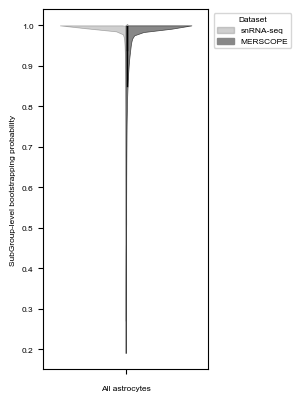

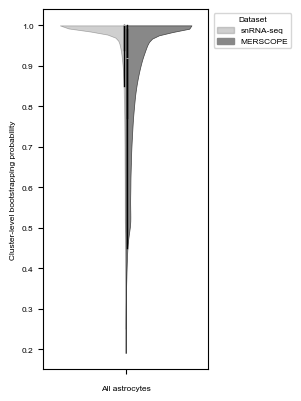

In [80]:
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

subgroup_palette = {key: adata_spatial_remap_astro.uns['SubGroup_color_dict'][key] for key in ['GM STR', 'WM', 'GM exSTR']}
astro_subgroups = list(subgroup_palette.keys())

combined_metrics_plot = combined_metrics.copy()
combined_metrics_plot['cluster_id_short'] = (
    combined_metrics_plot['CDM_cluster_id_label']
    .astype(str)
    .str.replace('Human-', 'h-', regex=False)
)
combined_metrics_plot['SubGroup'] = combined_metrics_plot['CDM_SubGroup_label'].astype(str)

PLOT_HEIGHT = 4

def recolor_split_violins(ax, color_full, color_faded, alpha_full=1.0, alpha_faded=0.4):
    """Re-color split violin halves: even idx = full, odd idx = faded."""
    violins = [c for c in ax.collections if isinstance(c, PolyCollection)]
    for i, poly in enumerate(violins):
        if i % 2 == 0:
            poly.set_facecolor(color_faded)
            poly.set_alpha(alpha_faded)
        else:
            poly.set_facecolor(color_full)
            poly.set_alpha(alpha_full)

# ── Plot 1: single split violin, SubGroup-level bootstrapping probability ─────
fig, ax = plt.subplots(figsize=(3, PLOT_HEIGHT))
sns.violinplot(
    data=combined_metrics_plot[combined_metrics_plot['SubGroup'].isin(astro_subgroups)],
    y='CDM_SubGroup_bootstrapping_probability',
    hue='dataset',
    split=True,
    inner='box',
    linewidth=0.5,
    ax=ax,
    cut=0,
)
# Lines include whiskers, box edges, medians
for line in ax.lines:
    line.set_color("black")     # or whatever you want
    line.set_linewidth(1.0)
recolor_split_violins(ax, color_full='#888888', color_faded='#888888', alpha_full=1.0, alpha_faded=0.4)
ax.set_xlabel('All astrocytes')
ax.set_ylabel('SubGroup-level bootstrapping probability')
ax.set_ylim(0.15, None)
legend_handles = [
    Patch(color='#888888', alpha=0.4, label='snRNA-seq'),
    Patch(color='#888888', alpha=1.0, label='MERSCOPE'),
]
ax.legend(handles=legend_handles, title='Dataset', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_fig_dir, 'subgroup_bootstrapping_violin_split_allCells.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'subgroup_bootstrapping_violin_split_allCells.png'), bbox_inches='tight', dpi=300)

# ── Plot 2: single split violin, cluster-level bootstrapping probability ──────
fig, ax = plt.subplots(figsize=(3, PLOT_HEIGHT))
sns.violinplot(
    data=combined_metrics_plot[combined_metrics_plot['SubGroup'].isin(astro_subgroups)],
    y='CDM_cluster_id_bootstrapping_probability',
    hue='dataset',
    split=True,
    inner='box',
    linewidth=0.5,
    ax=ax,
    cut=0,
)
# Lines include whiskers, box edges, medians
for line in ax.lines:
    line.set_color("black")     # or whatever you want
    line.set_linewidth(1.0)

recolor_split_violins(ax, color_full='#888888', color_faded='#888888', alpha_full=1.0, alpha_faded=0.4)
ax.set_xlabel('All astrocytes')
ax.set_ylabel('Cluster-level bootstrapping probability')
ax.set_ylim(0.15, None)
ax.legend(handles=legend_handles, title='Dataset', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_fig_dir, 'cluster_bootstrapping_violin_split_allCells.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'cluster_bootstrapping_violin_split_allCells.png'), bbox_inches='tight', dpi=300)


In [81]:
# per Cluster # of cells snrna-seq vs spatial
cluster_counts = (
    combined_metrics_plot
    .groupby(['CDM_cluster_id_label', 'dataset'], observed=True)
    .size()
    .reset_index(name='cell_count')
)


/tmp/ipykernel_133287/49768153.py:42: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, lim_max)
/tmp/ipykernel_133287/49768153.py:43: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, lim_max)


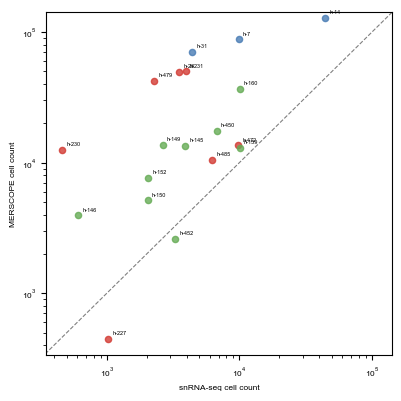

In [88]:
from matplotlib.patches import Patch

# ── Pivot to get one row per cluster with snRNA-seq and MERSCOPE counts ───────
scatter_data = (
    cluster_counts
    .pivot(index='cluster_id_short', columns='dataset', values='cell_count')
    .reset_index()
    .rename(columns={'snRNA-seq': 'n_rnaseq', 'MERSCOPE': 'n_merscope'})
    .fillna(0)
)
scatter_data['SubGroup'] = scatter_data['cluster_id_short'].map(
    combined_metrics_plot.drop_duplicates('cluster_id_short')
    .set_index('cluster_id_short')['SubGroup']
)
scatter_data = scatter_data[scatter_data['SubGroup'].isin(astro_subgroups)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 4))

for subgroup in astro_subgroups:
    sg = scatter_data[scatter_data['SubGroup'] == subgroup]
    ax.scatter(
        sg['n_rnaseq'], sg['n_merscope'],
        color=subgroup_palette[subgroup],
        label=subgroup,
        s=20, alpha=0.8, zorder=3,
    )
    # optional: label each point
    for _, row in sg.iterrows():
        ax.annotate(
            row['cluster_id_short'],
            (row['n_rnaseq'], row['n_merscope']),
            fontsize=4, xytext=(3, 3), textcoords='offset points',
        )

# diagonal reference line (y = x)
lim_max = max(scatter_data['n_rnaseq'].max(), scatter_data['n_merscope'].max()) * 1.1
ax.plot([0, lim_max], [0, lim_max], color='gray', linewidth=0.8,
        linestyle='--', zorder=1, label='y = x')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)
ax.set_xlabel('snRNA-seq cell count')
ax.set_ylabel('MERSCOPE cell count')
# ax.legend(title='SubGroup', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)


plt.tight_layout()
plt.show()

fig.savefig(os.path.join(output_fig_dir, 'cluster_cell_counts_scatter_rna_vs_spatial.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'cluster_cell_counts_scatter_rna_vs_spatial.png'), bbox_inches='tight', dpi=300)